In [79]:
import pandas as pd

In [80]:
df = pd.read_csv("202601_202606_연령별인구현황_월간.csv", encoding="cp949")

In [81]:
df.head()

,행정구역,2026년01월_거주자_총인구수,2026년01월_거주자_연령구간인구수,2026년01월_거주자_0~9세,2026년01월_거주자_10~19세,2026년01월_거주자_20~29세,2026년01월_거주자_30~39세,2026년01월_거주자_40~49세,2026년01월_거주자_50~59세,2026년01월_거주자_60~69세,...,2026년06월_여_거주자_10~19세,2026년06월_여_거주자_20~29세,2026년06월_여_거주자_30~39세,2026년06월_여_거주자_40~49세,2026년06월_여_거주자_50~59세,2026년06월_여_거주자_60~69세,2026년06월_여_거주자_70~79세,2026년06월_여_거주자_80~89세,2026년06월_여_거주자_90~99세,2026년06월_여_거주자_100세 이상
0,서울특별시 강남구 (1168000000),"548,767","548,767","31,839","63,729","62,434","79,541","98,437","86,861","62,427",...,"30,428","32,508","41,641","53,105","43,620","32,885","24,779","9,373","1,967",68
1,서울특별시 강남구 신사동(1168051000),"14,759","14,759",778,"1,441","1,742","1,893","2,298","2,541","1,717",...,750,924,"1,001","1,227","1,343",889,813,420,81,5
2,서울특별시 강남구 논현1동(1168052100),"20,080","20,080",479,822,"3,300","5,152","3,417","2,688","2,055",...,411,"1,834","2,537","1,833","1,350","1,105",836,358,62,3
3,서울특별시 강남구 논현2동(1168053100),"19,600","19,600",778,"1,168","2,732","4,024","3,483","3,024","2,056",...,582,"1,507","2,123","1,860","1,582","1,100",905,390,72,4
4,서울특별시 강남구 압구정동(1168054500),"25,042","25,042","1,696","2,734","2,553","2,722","4,089","4,172","3,115",...,"1,415","1,319","1,478","2,236","2,201","1,628","1,451",681,140,3


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Columns: 235 entries, 행정구역 to 2026년06월_여_거주자_100세 이상
dtypes: int64(24), str(211)
memory usage: 42.4 KB


In [83]:
df.columns

Index(['행정구역', '2026년01월_거주자_총인구수', '2026년01월_거주자_연령구간인구수',
       '2026년01월_거주자_0~9세', '2026년01월_거주자_10~19세', '2026년01월_거주자_20~29세',
       '2026년01월_거주자_30~39세', '2026년01월_거주자_40~49세', '2026년01월_거주자_50~59세',
       '2026년01월_거주자_60~69세',
       ...
       '2026년06월_여_거주자_10~19세', '2026년06월_여_거주자_20~29세',
       '2026년06월_여_거주자_30~39세', '2026년06월_여_거주자_40~49세',
       '2026년06월_여_거주자_50~59세', '2026년06월_여_거주자_60~69세',
       '2026년06월_여_거주자_70~79세', '2026년06월_여_거주자_80~89세',
       '2026년06월_여_거주자_90~99세', '2026년06월_여_거주자_100세 이상'],
      dtype='str', length=235)

In [84]:
# 첫번째 행이 강남구고 그 다음부터 동이라서 첫번째 행을 빼는게 좋음
dong_df = df.iloc[1:].copy()

In [85]:
# 지도에서 1~6월을 선택할 수 있도록 모든 월의 총인구와 연령대별 열을 남깁니다.
months = [f"2026년{month:02d}월" for month in range(1, 7)]
age_groups = [
    "0~9세", "10~19세", "20~29세", "30~39세",
    "40~49세", "50~59세", "60~69세", "70~79세",
    "80~89세", "90~99세", "100세 이상"
]

columns = ["행정구역"]
for month in months:
    columns.append(f"{month}_거주자_총인구수")
    columns.extend(f"{month}_거주자_{age}" for age in age_groups)

dong_df = dong_df[columns]

In [86]:
#데이터가 14,697처럼 ,가 있어서 바꿔줘야함. -> 데이터 전처리
for col in dong_df.columns[1:]:
    dong_df[col] = (
        dong_df[col]
        .astype(str)
        .str.replace(",", "")
        .astype(int)
    )

In [87]:
#동 이름이 서울특별시 강남구 신사동(번호) 이렇게 길어서 이걸 신사동 이렇게 짧게 만들어주는 과정
dong_df["동이름"] = (
    dong_df["행정구역"]
    .str.extract(r"강남구\s+([^(]+)")[0]
    .str.strip()
)

In [88]:
dong_df[["행정구역", "동이름"]].head()

,행정구역,동이름
1,서울특별시 강남구 신사동(1168051000),신사동
2,서울특별시 강남구 논현1동(1168052100),논현1동
3,서울특별시 강남구 논현2동(1168053100),논현2동
4,서울특별시 강남구 압구정동(1168054500),압구정동
5,서울특별시 강남구 청담동(1168056500),청담동


이제 이걸 코드로 볼꺼면 터미널에
- sudo apt update
- sudo apt install fonts-nanum
한 후

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
이걸 사용

In [89]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

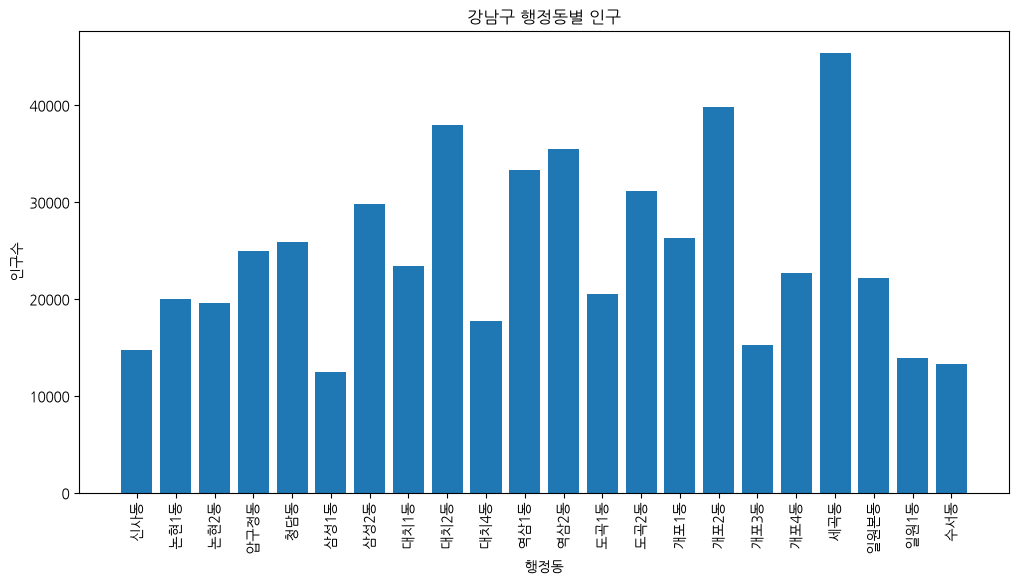

In [90]:
plt.figure(figsize=(12, 6))

plt.bar(
    dong_df["동이름"],
    dong_df["2026년06월_거주자_총인구수"]
)

plt.title("강남구 행정동별 인구")
plt.xlabel("행정동")
plt.ylabel("인구수")

plt.xticks(rotation=90)

plt.show()

In [91]:
# 위 그래프는 시각적으로 잘 안보임. 인구순으로 정렬한 후 보면 더 좋음.
sorted_df = dong_df.sort_values(
    "2026년06월_거주자_총인구수",
    ascending=False
)

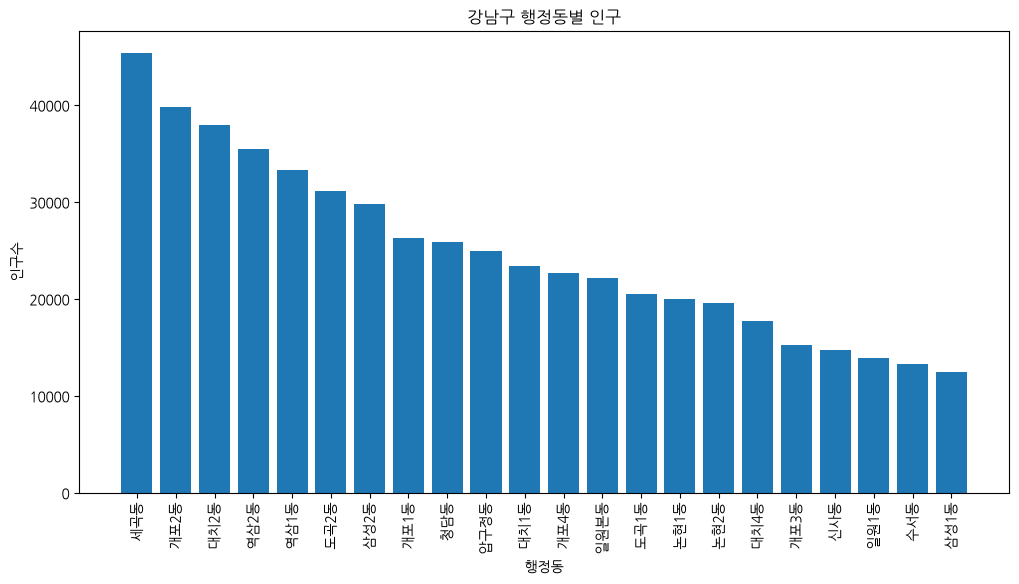

In [92]:
plt.figure(figsize=(12, 6))

plt.bar(
    sorted_df["동이름"],
    sorted_df["2026년06월_거주자_총인구수"]
)

plt.title("강남구 행정동별 인구")
plt.xlabel("행정동")
plt.ylabel("인구수")

plt.xticks(rotation=90)

plt.show()

Folium 지도 위에 각 동의 중심 좌표를 찍고, CircleMarker에 tooltip을 넣는 방식 사용해보기
- uv add folium geopy

In [93]:
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

coordinate_file = Path("gangnam_coordinates.csv")
old_coordinate_file = Path("gangnam_population_with_location.csv")

if coordinate_file.exists():
    coordinates = pd.read_csv(coordinate_file)
elif old_coordinate_file.exists():
    coordinates = pd.read_csv(old_coordinate_file)[["동이름", "주소", "위도", "경도"]]
    coordinates.to_csv(coordinate_file, index=False, encoding="utf-8-sig")
else:
    geolocator = Nominatim(
        user_agent="gangnam_population_map",
        timeout=10
    )

    geocode = RateLimiter(
        geolocator.geocode,
        min_delay_seconds=1,
        max_retries=2,
        error_wait_seconds=2,
        swallow_exceptions=True
    )

In [94]:
if not coordinate_file.exists():
    coordinates = dong_df[["동이름"]].copy()
    coordinates["주소"] = "서울특별시 강남구 " + coordinates["동이름"]

In [95]:
if not coordinate_file.exists():
    coordinates["location"] = coordinates["주소"].apply(geocode)

In [96]:
if not coordinate_file.exists():
    coordinates["위도"] = coordinates["location"].apply(
        lambda x: x.latitude if x else None
    )
    coordinates["경도"] = coordinates["location"].apply(
        lambda x: x.longitude if x else None
    )
    coordinates = coordinates[["동이름", "주소", "위도", "경도"]]
    coordinates.to_csv(coordinate_file, index=False, encoding="utf-8-sig")

In [97]:
coordinates[coordinates["위도"].isna()][["동이름", "주소"]]

,동이름,주소


In [98]:
dong_df = dong_df.drop(columns=["주소", "location", "위도", "경도"], errors="ignore")
dong_df = dong_df.merge(
    coordinates[["동이름", "주소", "위도", "경도"]],
    on="동이름",
    how="left",
    validate="one_to_one"
)

In [99]:
dong_df[dong_df["위도"].isna()][["동이름", "주소"]]

,동이름,주소


In [100]:
dong_df[["동이름", "위도", "경도"]]

,동이름,위도,경도
0,신사동,37.522321,127.027702
1,논현1동,37.511867,127.026302
2,논현2동,37.513730,127.036716
3,압구정동,37.530043,127.031335
4,청담동,37.525754,127.052322
5,삼성1동,37.516043,127.059793
6,삼성2동,37.513730,127.047821
7,대치1동,37.494061,127.058679
8,대치2동,37.500274,127.066666
9,대치4동,37.501679,127.054869


In [101]:
import folium
from branca.element import MacroElement, Template

map_df = dong_df.dropna(subset=["위도", "경도"]).copy()

m = folium.Map(
    location=[map_df["위도"].mean(), map_df["경도"].mean()],
    zoom_start=13
)
m.fit_bounds(
    [[map_df["위도"].min(), map_df["경도"].min()],
     [map_df["위도"].max(), map_df["경도"].max()]],
    padding=(30, 30)
)

# 월별 마커 그룹을 모두 만든 뒤 드롭다운에서 선택한 한 달만 표시합니다.
month_layers = {}
for month in months:
    population_col = f"{month}_거주자_총인구수"
    max_population = map_df[population_col].max()
    layer = folium.FeatureGroup(name=month, show=True).add_to(m)
    month_layers[month] = layer

    for _, row in map_df.iterrows():
        population = row[population_col]
        radius = population / max_population * 20 + 5

        age_rows = "".join(
            f"<tr><td>{age}</td><td style='text-align:right'>{row[f'{month}_거주자_{age}']:,}명</td></tr>"
            for age in age_groups
        )
        popup_html = (
            f"<div style='width:240px'>"
            f"<h4 style='margin:0 0 8px'>{row['동이름']} · {month}</h4>"
            f"<b>총인구: {population:,}명</b>"
            f"<table style='width:100%;margin-top:8px;border-collapse:collapse'>"
            f"{age_rows}</table></div>"
        )

        folium.CircleMarker(
            location=[row["위도"], row["경도"]],
            radius=radius,
            tooltip=f'<b>{row["동이름"]}</b><br>인구: {population:,}명',
            popup=folium.Popup(popup_html, max_width=280),
            color="#2563eb",
            fill=True,
            fill_color="#3b82f6",
            fill_opacity=0.7
        ).add_to(layer)

# Folium/Leaflet 오른쪽 위에 월 선택 드롭다운을 추가합니다.
class MonthSelector(MacroElement):
    def __init__(self, layers, default_month):
        super().__init__()
        self._name = "MonthSelector"
        self.layers = layers
        self.default_month = default_month
        self._template = Template("""
        {% macro script(this, kwargs) %}
        const monthLayers = {
        {% for label, layer in this.layers.items() %}
            {{ label|tojson }}: {{ layer.get_name() }},
        {% endfor %}
        };
        const MonthControl = L.Control.extend({
            options: {position: 'topright'},
            onAdd: function(map) {
                const box = L.DomUtil.create('div', 'leaflet-bar');
                box.style.background = 'white';
                box.style.padding = '8px';
                box.innerHTML = `<label style="font-weight:bold;margin-right:6px">월</label>
                    <select id="population-month" style="padding:4px"></select>`;
                const select = box.querySelector('select');
                Object.keys(monthLayers).forEach(function(month) {
                    const option = document.createElement('option');
                    option.value = month;
                    option.textContent = month;
                    option.selected = month === {{ this.default_month|tojson }};
                    select.appendChild(option);
                    if (month !== {{ this.default_month|tojson }}) map.removeLayer(monthLayers[month]);
                });
                select.addEventListener('change', function(event) {
                    Object.values(monthLayers).forEach(layer => map.removeLayer(layer));
                    map.addLayer(monthLayers[event.target.value]);
                });
                L.DomEvent.disableClickPropagation(box);
                return box;
            }
        });
        {{ this._parent.get_name() }}.addControl(new MonthControl());

        // Jupyter 출력 영역의 크기가 바뀌면 타일과 마커 위치를 다시 계산합니다.
        const populationMap = {{ this._parent.get_name() }};
        const mapContainer = populationMap.getContainer();
        const refreshMapSize = () => populationMap.invalidateSize({pan: false});
        setTimeout(refreshMapSize, 0);
        setTimeout(refreshMapSize, 300);
        setTimeout(refreshMapSize, 1000);
        if (window.ResizeObserver) {
            new ResizeObserver(refreshMapSize).observe(mapContainer);
        }
        window.addEventListener('resize', refreshMapSize);
        {% endmacro %}
        """)

MonthSelector(month_layers, default_month=months[-1]).add_to(m)

# 아래 워드클라우드 셀에서도 최신 월(6월)을 사용합니다.
population_col = f"{months[-1]}_거주자_총인구수"

In [102]:
m.save("gangnam_population_map.html")
m

## 동 선택형 월별 인구 변화 막대그래프

드롭다운에서 동을 선택하면 바로 전월 대비 월별 증감이 표시됩니다. 1월은 비교할 전월이 없어 기준값 0명으로 표시하며, 툴팁에서 실제 인구수도 확인할 수 있습니다.

In [103]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

dong_names = dong_df["동이름"].tolist()
month_labels = [f"{int(month[5:7])}월" for month in months]
default_dong = dong_names[0]

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("전월 대비 전체 인구 증감", "전월 대비 연령대별 인구 증감"),
    vertical_spacing=0.16
)

# 절대 인구수 대신 전월 대비 증감을 그려 작은 변화도 잘 보이게 합니다.
traces_per_dong = 1 + len(age_groups)
for dong in dong_names:
    row = dong_df.loc[dong_df["동이름"] == dong].iloc[0]
    is_default = dong == default_dong

    total_values = [row[f"{month}_거주자_총인구수"] for month in months]
    total_deltas = [0] + [
        total_values[index] - total_values[index - 1]
        for index in range(1, len(total_values))
    ]
    delta_labels = ["비교 없음"] + [f"{value:+,}명" for value in total_deltas[1:]]
    total_colors = ["#dc2626" if value < 0 else "#2563eb" for value in total_deltas]
    fig.add_trace(
        go.Bar(
            x=month_labels, y=total_deltas, customdata=total_values, name="전체 인구 증감",
            marker_color=total_colors, text=delta_labels, texttemplate="%{text}",
            textposition="outside", cliponaxis=False,
            visible=is_default, showlegend=False,
            hovertemplate="%{x}<br>실제 인구: %{customdata:,}명<br>전월 대비: %{y:+,}명<extra></extra>"
        ),
        row=1, col=1
    )

    for age in age_groups:
        age_values = [row[f"{month}_거주자_{age}"] for month in months]
        age_deltas = [0] + [
            age_values[index] - age_values[index - 1]
            for index in range(1, len(age_values))
        ]
        fig.add_trace(
            go.Bar(
                x=month_labels, y=age_deltas, customdata=age_values,
                name=age, visible=is_default,
                hovertemplate=(
                    f"%{{x}} · {age}<br>실제 인구: %{{customdata:,}}명"
                    f"<br>전월 대비: %{{y:+,}}명<extra></extra>"
                )
            ),
            row=2, col=1
        )

buttons = []
for dong_index, dong in enumerate(dong_names):
    visible = [False] * (len(dong_names) * traces_per_dong)
    start = dong_index * traces_per_dong
    visible[start:start + traces_per_dong] = [True] * traces_per_dong
    buttons.append(dict(
        label=dong, method="update",
        args=[{"visible": visible}, {
            "title": f"{dong} 인구 변화 (2026년 1~6월)",
            "yaxis.autorange": True, "yaxis2.autorange": True
        }]
    ))

fig.update_layout(
    title=f"{default_dong} 인구 변화 (2026년 1~6월)",
    height=850, barmode="group", hovermode="closest",
    margin=dict(t=130, r=140, b=70, l=80),
    legend=dict(
        title_text="연령대",
        x=1.02, xanchor="left",
        y=0.24, yanchor="middle"
    ),
    updatemenus=[dict(
        buttons=buttons, direction="down", showactive=True,
        x=1, xanchor="right", y=1.16, yanchor="top"
    )],
    annotations=list(fig.layout.annotations) + [dict(
        text="동 선택", x=0.82, y=1.135, xref="paper", yref="paper",
        showarrow=False, font=dict(size=13)
    )]
)
fig.update_yaxes(
    title_text="전월 대비 증감(명)", zeroline=True, zerolinewidth=2,
    zerolinecolor="#374151", automargin=True, row=1, col=1
)
fig.update_yaxes(
    title_text="전월 대비 증감(명)", zeroline=True, zerolinewidth=2,
    zerolinecolor="#374151", row=2, col=1
)
fig.update_xaxes(title_text="2026년", row=2, col=1)
fig.show()

# 연령대별 공공시설 공급 분석

공공건축물을 이용 대상에 따라 분류하고, 시설 주소를 행정동과 연결한 뒤 동별 연령 인구와 비교합니다.

### 1. 시설 불러오기 및 대상 연령 분류

시설명에 포함된 단어를 기준으로 아동·청소년, 청년, 중장년, 노년, 전 연령 시설을 구분합니다. 주민 이용시설이 아닌 행정지원기관은 제외합니다.

In [107]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import Nominatim

facilities = pd.read_csv("서울특별시 강남구_공공건축물_20230320.csv", encoding="cp949")

rules = {
    "아동·청소년": r"어린이|아동|청소년|유아|육아|키즈",
    "청년": r"청년|취창업|창업허브",
    "중장년": r"중장년|중년|50플러스|오십플러스",
    "노년": r"노인|시니어|실버|경로당|데이케어|요양",
    "전 연령": r"평생학습|복합문화|문화센터|정보문화도서관|커뮤니티센터|체육관|배드민턴장",
}

def target_age(name):
    if re.search(r"급식관리지원센터|지역자활센터", str(name)):
        return None
    return next((age for age, pattern in rules.items() if re.search(pattern, str(name))), None)

facilities["대상연령"] = facilities["시설명"].apply(target_age)
facilities = facilities.dropna(subset=["대상연령"]).copy()

### 2. 도로명주소 지오코딩

시설의 도로명주소를 위도·경도로 변환합니다. 최초 실행 결과를 CSV로 저장하므로 다음 실행부터는 외부 요청 없이 좌표를 재사용합니다.

In [108]:
coordinate_path = Path("gangnam_facility_coordinates.csv")

if coordinate_path.exists():
    coordinates = pd.read_csv(coordinate_path, encoding="utf-8-sig")
else:
    geocode = RateLimiter(
        Nominatim(user_agent="gangnam_age_facility_analysis", timeout=10).geocode,
        min_delay_seconds=1, max_retries=2, swallow_exceptions=True
    )
    coordinates = facilities[["주소(도로명)"]].drop_duplicates().copy()
    coordinates["검색결과"] = coordinates["주소(도로명)"].apply(geocode)
    coordinates["위도"] = coordinates["검색결과"].apply(lambda x: x.latitude if x else np.nan)
    coordinates["경도"] = coordinates["검색결과"].apply(lambda x: x.longitude if x else np.nan)
    coordinates.drop(columns="검색결과").to_csv(coordinate_path, index=False, encoding="utf-8-sig")

facilities = facilities.merge(coordinates, on="주소(도로명)", how="left")
failed_count = facilities[["위도", "경도"]].isna().any(axis=1).sum()
print(f"좌표 변환 성공: {len(facilities) - failed_count}개 / 실패: {failed_count}개")
facilities = facilities.dropna(subset=["위도", "경도"])

좌표 변환 성공: 80개 / 실패: 3개


### 3. 좌표와 행정동 경계 결합

행정동 GeoJSON을 내려받고, 각 시설 좌표가 어느 행정동 경계 안에 있는지 판별하여 `동이름`을 자동으로 부여합니다.

In [109]:
boundary_path = Path("HangJeongDong_ver20260401.geojson")
boundary_url = (
    "https://raw.githubusercontent.com/vuski/admdongkor/master/"
    "ver20260401/HangJeongDong_ver20260401.geojson"
)

if not boundary_path.exists():
    response = requests.get(boundary_url, timeout=60)
    response.raise_for_status()
    boundary_path.write_bytes(response.content)

with boundary_path.open(encoding="utf-8") as file:
    boundaries = json.load(file)["features"]
gangnam_boundaries = [f for f in boundaries if "강남구" in f["properties"]["adm_nm"]]

def inside_ring(x, y, ring):
    inside = False
    for i in range(len(ring)):
        x1, y1 = ring[i - 1][:2]
        x2, y2 = ring[i][:2]
        if (y1 > y) != (y2 > y) and x < (x2 - x1) * (y - y1) / (y2 - y1) + x1:
            inside = not inside
    return inside

def inside_geometry(x, y, geometry):
    polygons = [geometry["coordinates"]] if geometry["type"] == "Polygon" else geometry["coordinates"]
    return any(inside_ring(x, y, polygon[0]) for polygon in polygons)

def find_dong(row):
    for feature in gangnam_boundaries:
        if inside_geometry(row["경도"], row["위도"], feature["geometry"]):
            return feature["properties"]["adm_nm"].split()[-1]
    return np.nan

facilities["동이름"] = facilities.apply(find_dong, axis=1)
facilities = facilities.dropna(subset=["동이름"])

### 4. 결과표 ① 동별·대상 연령별 시설 수

각 행은 하나의 행정동입니다. 숫자는 해당 동에 있는 연령별 전용시설 수이며, `전 연령`은 특정 연령에 한정되지 않은 문화·체육·도서관 시설 수입니다. 이 표로 **어느 동에 어떤 종류의 시설이 몰려 있거나 부족한지** 비교할 수 있습니다.

In [110]:
facility_table = facilities.pivot_table(
    index="동이름", columns="대상연령", values="시설명", aggfunc="count", fill_value=0
).reindex(columns=rules.keys(), fill_value=0).reset_index()
display(facility_table)

대상연령,동이름,아동·청소년,청년,중장년,노년,전 연령
0,개포2동,0,0,0,1,2
1,개포3동,0,0,0,1,1
2,개포4동,0,0,0,3,2
3,논현1동,0,0,0,5,0
4,논현2동,0,0,0,4,0
5,대치1동,0,0,0,0,1
6,대치2동,0,0,0,1,2
7,대치4동,0,1,0,5,1
8,도곡1동,0,0,0,2,1
9,도곡2동,0,0,0,1,1


### 5. 결과표 ② 연령 전용시설 부족 우선 검토 대상

연령별 전용시설이 0개인 경우만 골라 해당 연령 인구가 많은 순으로 정렬한 표입니다. `전 연령 시설 수`가 적을수록 기존 시설을 활용하기도 어려운 동입니다. 따라서 **해당 연령 인구가 많고 전 연령 시설도 적은 동**을 복합문화센터 우선 검토지역으로 볼 수 있습니다.

In [111]:
population = pd.read_csv("gangnam_population_with_location.csv", encoding="utf-8-sig")
age_columns = {
    "아동·청소년": ["2026년06월_거주자_0~9세", "2026년06월_거주자_10~19세"],
    "청년": ["2026년06월_거주자_20~29세", "2026년06월_거주자_30~39세"],
    "중장년": ["2026년06월_거주자_40~49세", "2026년06월_거주자_50~59세"],
    "노년": ["2026년06월_거주자_60~69세", "2026년06월_거주자_70~79세",
             "2026년06월_거주자_80~89세", "2026년06월_거주자_90~99세",
             "2026년06월_거주자_100세 이상"],
}

for age, columns in age_columns.items():
    population[age] = population[columns].sum(axis=1)

combined = population[["동이름"] + list(age_columns)].merge(
    facility_table, on="동이름", how="left", suffixes=("_인구", "_시설")
).fillna(0)

rows = []
for _, row in combined.iterrows():
    for age in age_columns:
        if row[f"{age}_시설"] == 0:
            rows.append([row["동이름"], age, int(row[f"{age}_인구"]), int(row["전 연령"])])

shortage_table = pd.DataFrame(
    rows, columns=["동이름", "부족 연령층", "해당 연령 인구", "전 연령 시설 수"]
).sort_values("해당 연령 인구", ascending=False).head(15).reset_index(drop=True)
display(shortage_table)
print("※ 시설 규모·프로그램·접근성은 포함하지 않은 시설 수 기준의 1차 검토 결과입니다.")

,동이름,부족 연령층,해당 연령 인구,전 연령 시설 수
0,역삼1동,청년,15499,1
1,대치2동,중장년,14076,2
2,세곡동,중장년,13999,1
3,역삼2동,중장년,13986,1
4,개포2동,중장년,13676,2
5,세곡동,청년,12310,1
6,도곡2동,중장년,10983,1
7,삼성2동,중장년,10869,1
8,역삼1동,중장년,10260,1
9,개포2동,청년,9414,2


※ 시설 규모·프로그램·접근성은 포함하지 않은 시설 수 기준의 1차 검토 결과입니다.
